# MaalstroomicFlow — combined behavior and tuning diagnostics

Per-animal MaalstroomicFlow workspace: drives the behavior (lick scatter, trial outcomes) and tuning (text summary, sorted / classified heatmaps, cue-gray pair counts) plot helpers from a single selection. Edit the selection cell in section 2 to switch dataset, animal, session range, or trial type — every downstream cell consumes the resolved selection without further edits. Section 4 (behavior) and section 5 (tuning) cells are thin caller stubs over the same helpers used by `src/sollertia_forgery/analysis/notebooks/{behavior,tuning}.ipynb`.

## 1. Setup

Imports for the rest of the notebook. Run once per kernel restart; `%autoreload` keeps package edits live so re-running plot cells picks up helper changes without reloading.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import cmocean
from ataraxis_base_utilities import LogLevel, console

from sollertia_forgery.shared_assets import DatasetData
from sollertia_forgery.analysis import (
    LickContext,
    TrialOutcomeContext,
    TuningReport,
    aggregate_lick_events,
    aggregate_trial_outcomes,
    plot_classified_heatmap,
    plot_cue_pair_place_counts,
    plot_lick_scatter,
    plot_sorted_heatmap,
    plot_trial_outcomes,
)

## 2. Selection

The only cell to edit when switching datasets, animals, sessions, or trial types. `DATASET_PATH` is the dataset root, `ANIMAL` is a single animal id, `DISPLAY_SESSIONS` is a tuple of 1-indexed chronological session numbers shared by every per-session plot below (`None` renders every session in the animal's list), and `TRIAL_TYPE` selects which trial type the tuning helpers evaluate (set to `None` to fall back to the first trial type in each helper's own resolution path).

In [2]:
DATASET_PATH: Path = Path("/home/data/Data/void")
ANIMAL: str = "15"
DISPLAY_SESSIONS: tuple[int, ...] | None = (11, 12, 13, 14, 15)
TRIAL_TYPE: str | None = None

## 3. Load

Reads the dataset, builds the chronologically sorted `sessions` tuple for the selected animal, and assembles the per-animal behavior contexts (`lick_context`, `outcome_context`) consumed by section 4. Tuning helpers in section 5 read `sessions`, `DISPLAY_SESSIONS`, and `trial_type` directly.

In [3]:
dataset = DatasetData.load(dataset_path=DATASET_PATH)
sessions = tuple(
    sorted(
        dataset.get_sessions_for_animal(animal=ANIMAL),
        key=lambda dataset_session: dataset_session.session,
    )
)
if not sessions:
    raise RuntimeError(f"animal {ANIMAL!r} has no sessions in dataset {dataset.name!r}")

lick_context: LickContext = aggregate_lick_events(sessions=sessions)
outcome_context: TrialOutcomeContext = aggregate_trial_outcomes(sessions=sessions)
trial_type: str | None = TRIAL_TYPE

console.echo(message=f"Dataset: {dataset.name} ({DATASET_PATH})", level=LogLevel.INFO)
console.echo(
    message=(
        f"Animal {ANIMAL}, {len(sessions)} sessions available; "
        f"display={DISPLAY_SESSIONS if DISPLAY_SESSIONS is not None else 'all'}; "
        f"trial type {trial_type!r}"
    ),
    level=LogLevel.INFO,
)

2026-05-03 12:42:00.644 | INFO     | Dataset: void (/home/data/Data/void)
2026-05-03 12:42:00.645 | INFO     | Animal 15, 20 sessions available; display=(11, 12, 13, 14, 15); trial type None


## 4. Behavior outputs

Per-animal behavior plots restricted to `DISPLAY_SESSIONS`. Helpers return `matplotlib.figure.Figure`; the notebook just calls `plt.show()` so the figures render inline.

### 4.1 Lick scatter

Discrete rising-edge lick events scattered in (within-trial position, cumulative trial index) coordinates, with per-trial reward-zone rectangles drawn from each block's resolved geometry. Trial-type and geometry shifts (longitudinal mid-recording reward-zone shifts or intra-session multi-trial-type recordings) appear as different per-trial rectangles with the same color coding (rewarded vs non-rewarded relative to the trial's own reward zone).

Uses `DISPLAY_SESSIONS` from the selection cell to pick which sessions to render.

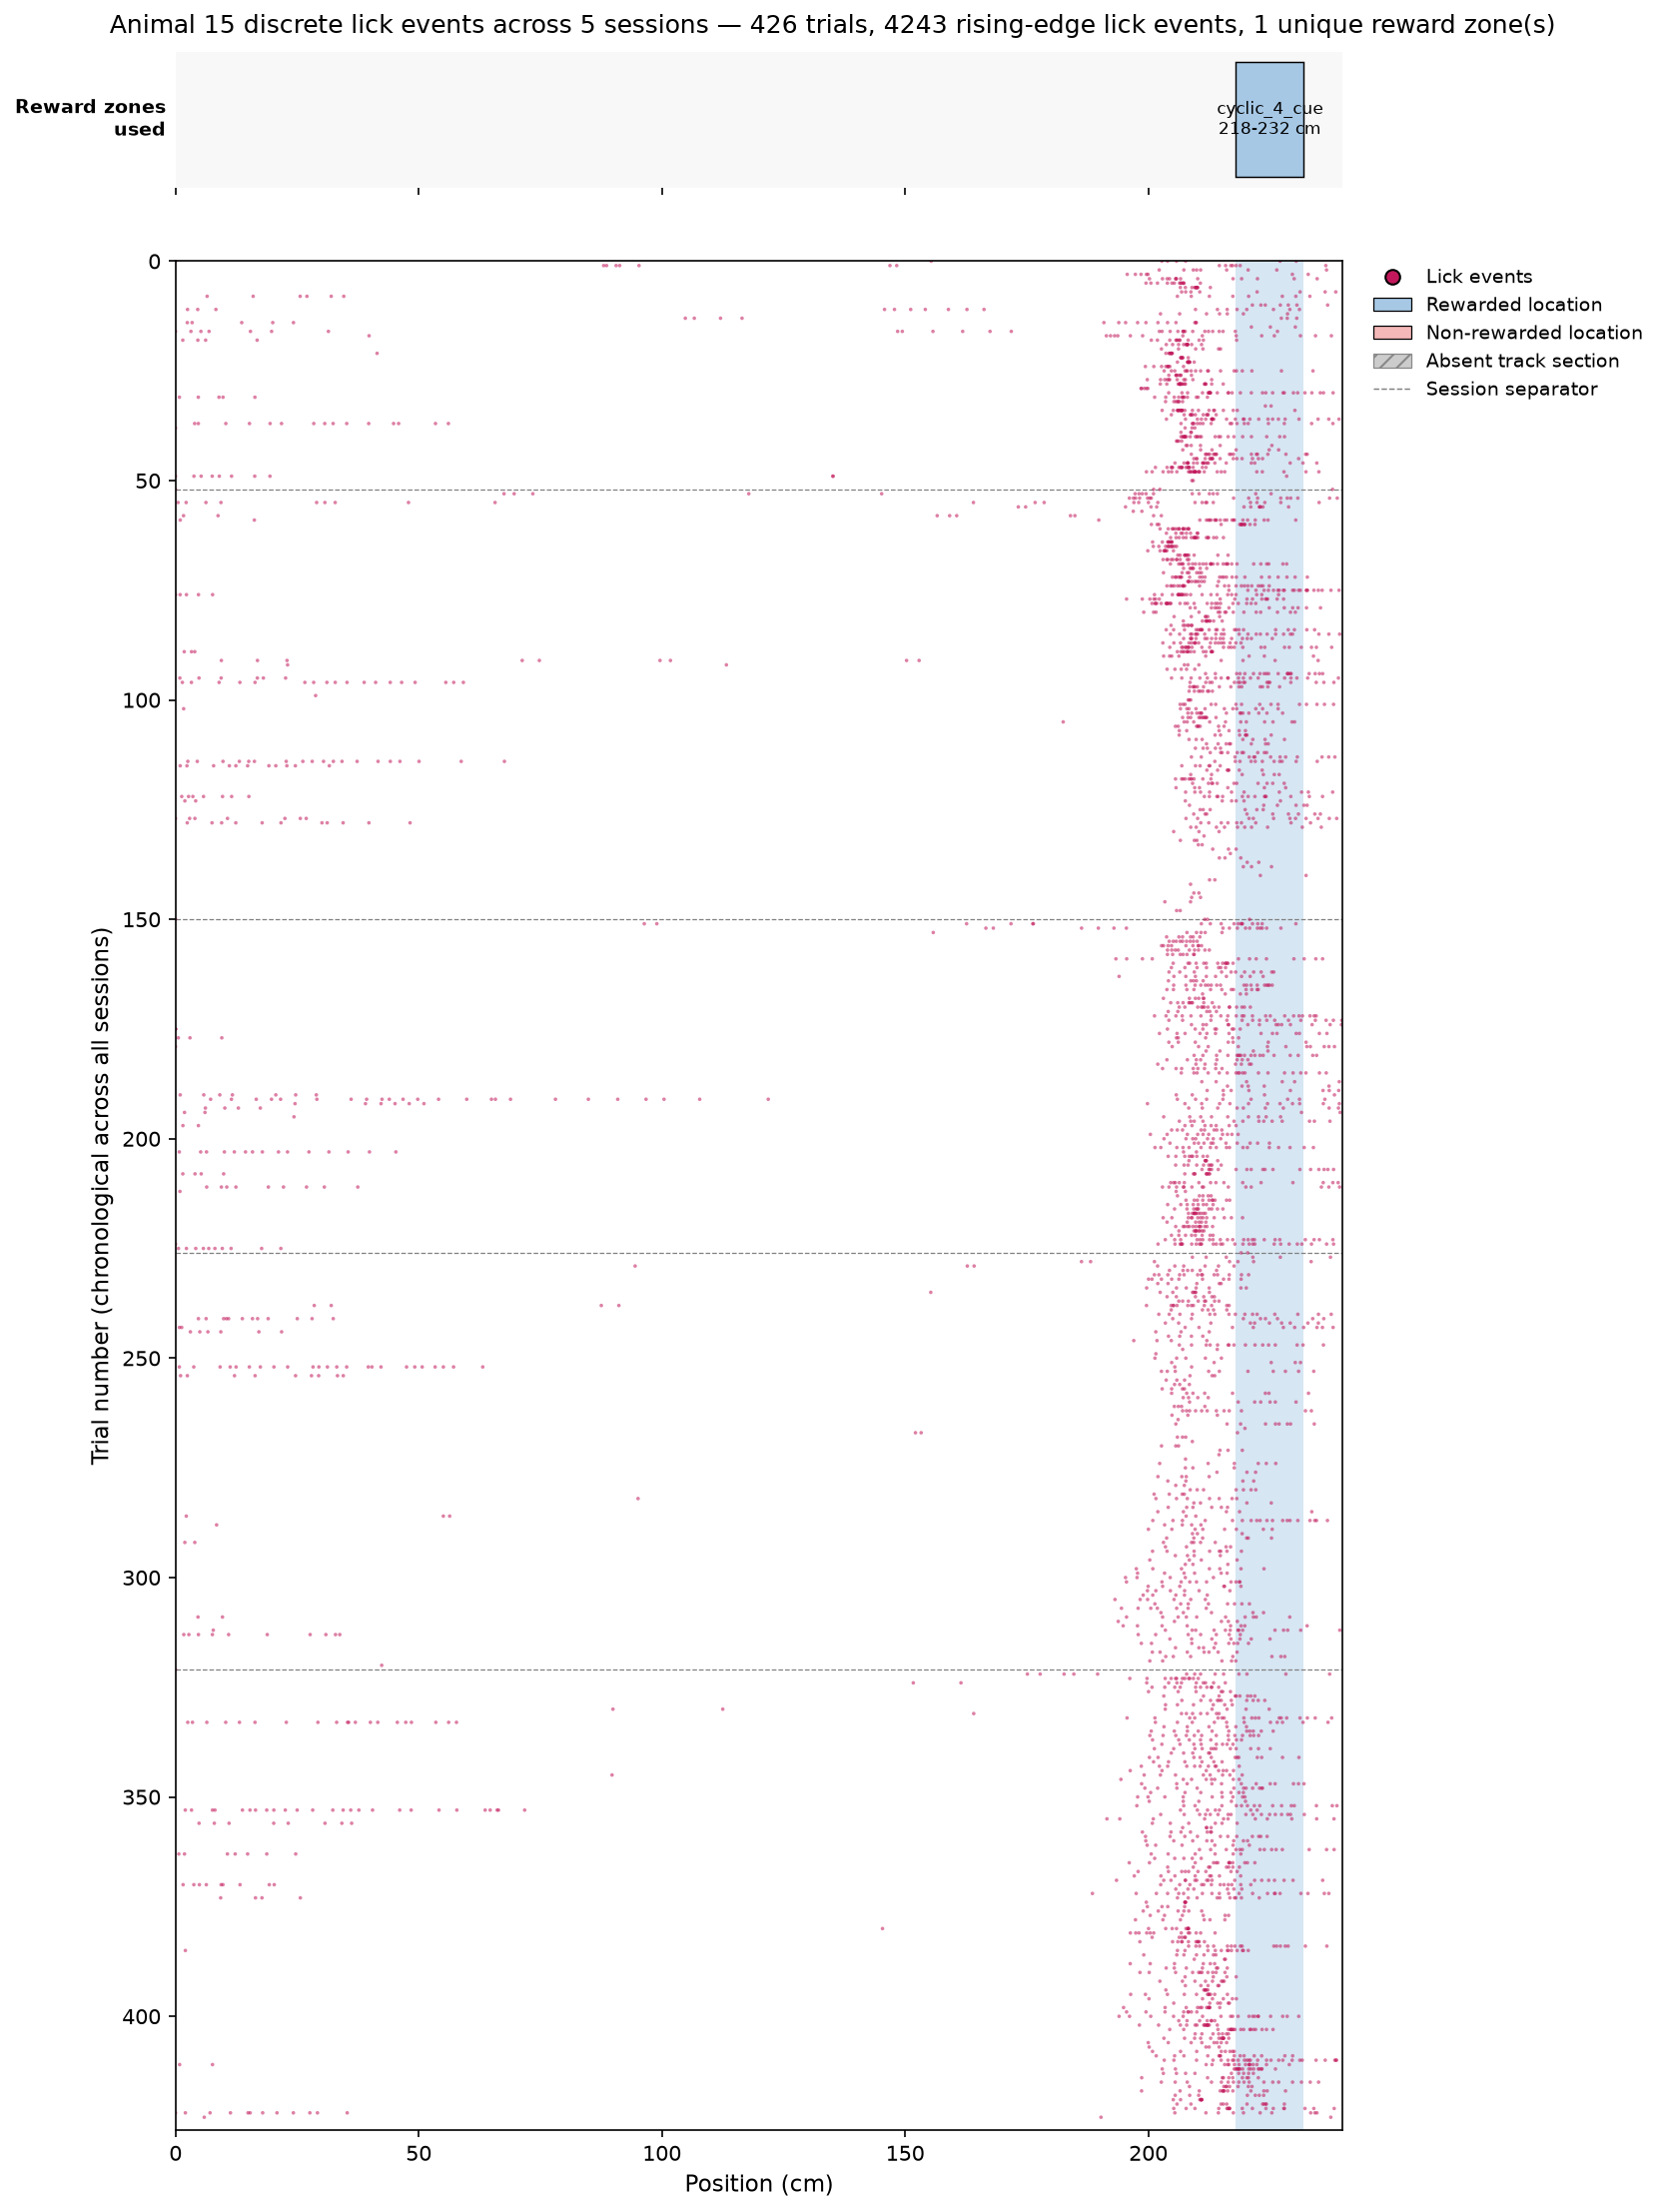

In [4]:
plot_lick_scatter(
    context=lick_context,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
)
plt.show()

### 4.2 Trial outcomes across sessions

Per-session stacked bar chart of success / failure / guided trial counts for the animal, with a success-rate trace overlaid on a secondary y-axis. A trial is classified as **guided** when any of its samples has ``reinforcing_guided`` or ``aversive_guided`` set; **success** when the trial is not guided and any sample has ``reward > 0``; **failure** otherwise. Guided trials are excluded from the success-rate denominator so the rate tracks the animal's earned-reward fraction rather than reflecting training-phase guidance.

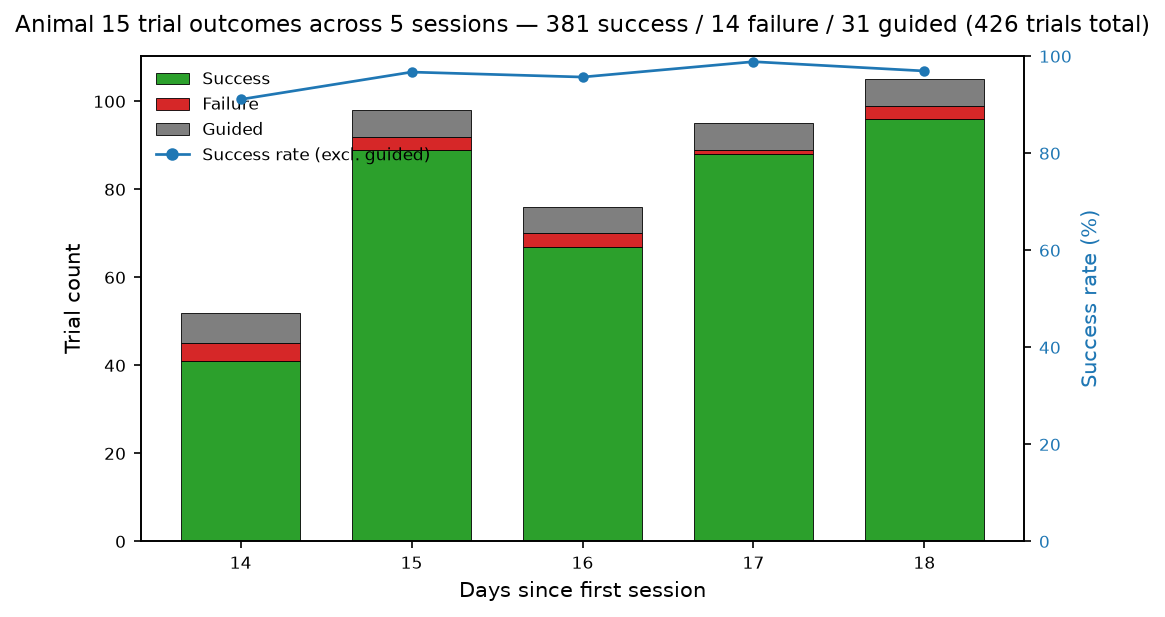

In [5]:
plot_trial_outcomes(
    context=outcome_context,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
)
plt.show()

## 5. Tuning outputs

Per-session tuning plots restricted to `DISPLAY_SESSIONS`. Each cell calls one helper from `sollertia_forgery.analysis.tuning.plotting` against `sessions` and `trial_type`.

### 5.1 Text summary

Iterates the resolved display sessions and prints each session's `TuningReport.summarize()` block.

In [6]:
selected_indices = (
    list(range(len(sessions)))
    if DISPLAY_SESSIONS is None
    else sorted({int(n) - 1 for n in DISPLAY_SESSIONS if 0 <= int(n) - 1 < len(sessions)})
)
for sess_idx in selected_indices:
    sess = sessions[sess_idx]
    console.echo(
        message=f"Animal {ANIMAL} session [{sess_idx + 1}] {sess.session} tuning summary",
        level=LogLevel.INFO,
    )
    console.echo(message=TuningReport.load(session=sess).summarize(), raw=True)

2026-05-03 12:42:01.284 | INFO     | Animal 15 session [11] 2025-07-28-12-21-49-464321 tuning summary
Tuning report
Cells: 3836
Trial types: cyclic_4_cue
Sampling rate: 10.00 Hz

Trial type: cyclic_4_cue
------------------------
  Track length:      240.0 cm
  Reward position:   225.0 cm
  Bin size:          5.0 cm (48 bins)
  Place-only:            2229 (58.1%)
  Reliable (lap cov.):   2556 (66.6%)
  Stable (split-half):   3159 (82.4%)
  Peak-significant:      3131 (81.6%)
  Strict place cells:    2193 (57.2%)
  Spatially significant: 3663 (95.5%)
  Reward cells:          543 (14.2%)
  Reward-predictive:     38 (1.0%)
  Reward mixture: weight 0.025, center 217.0 cm (SD 4.9 cm)
  Track-start wt: 0.000 (SD 10.9 cm)
  Track-end wt:   0.000 (SD 10.6 cm)
2026-05-03 12:42:01.328 | INFO     | Animal 15 session [12] 2025-07-29-12-49-17-013336 tuning summary
Tuning report
Cells: 3836
Trial types: cyclic_4_cue
Sampling rate: 10.00 Hz

Trial type: cyclic_4_cue
------------------------
  Track le

### 5.2 Per-day-sorted rate maps — all cells

Per-session view across the animal's selected session range: every registered cell renders as a row, sorted independently by *that session's* peak position. Rate maps are raw ΔF/F₀ on a shared percentile-clipped color scale so amplitudes are directly comparable between panels. Use this view for a global sense of the population's tuning band; pair with section 5.3 for the active-cell-only band.

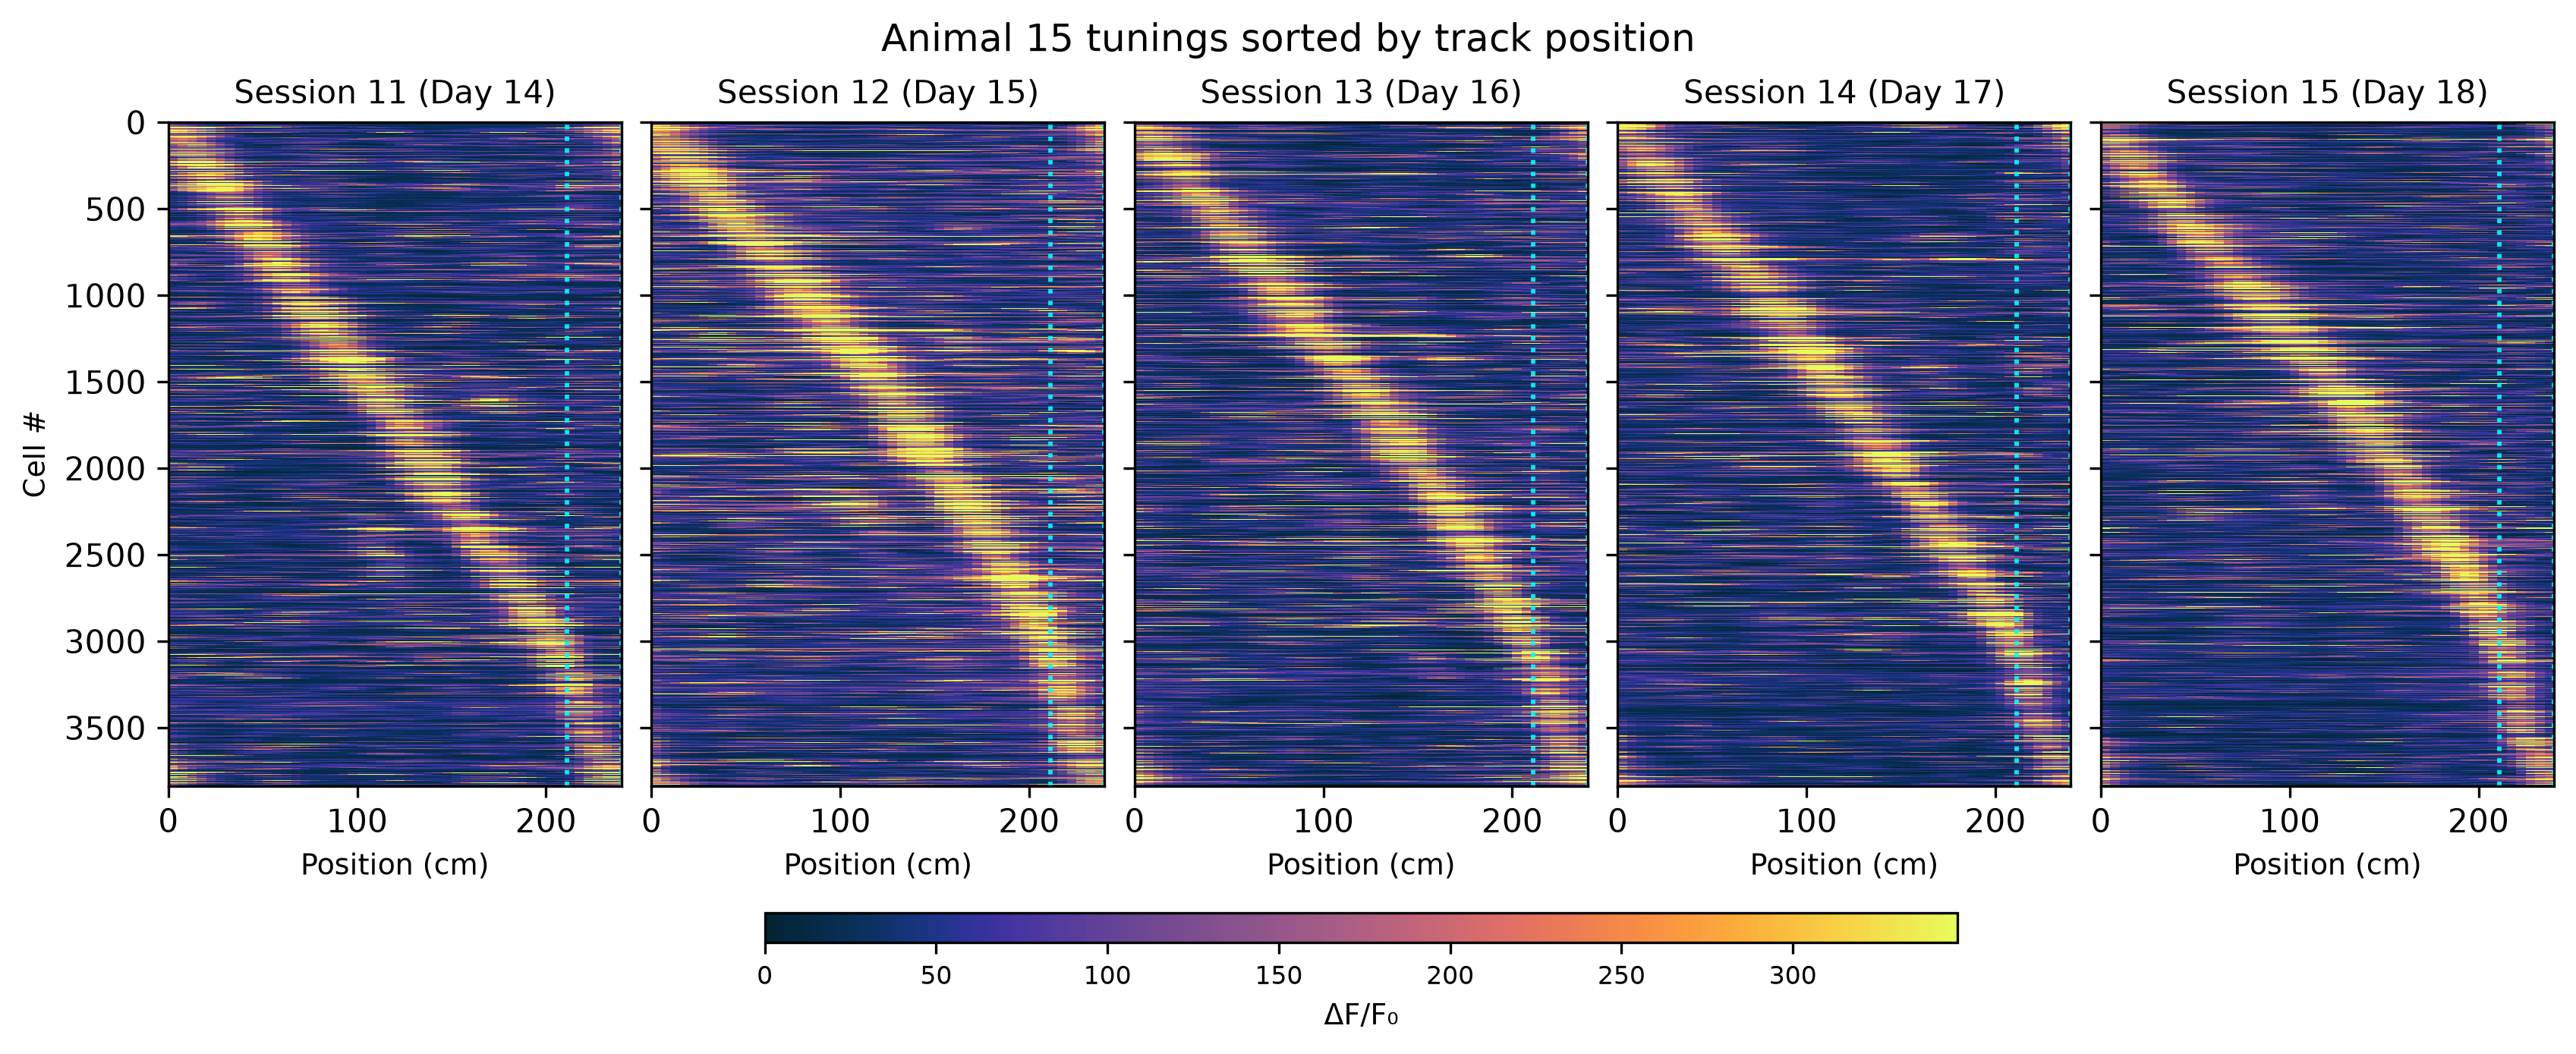

In [7]:
plot_sorted_heatmap(
    sessions=sessions,
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=300,
    cmap="cmo.thermal",
)
plt.show()

### 5.3 Per-day-sorted rate maps — classified cells

Per-session view restricted to one classifier-active subset. ``classifier="place"`` always selects ``IS_STRICT_PLACE`` (place-field morphology + lap coverage + split-half stability + per-cell peak shuffle); ``classifier="reward"`` selects ``IS_REWARD_CELL``. Each cell's row is divided by its own peak so the colorbar is fixed at ``[0, 1]`` regardless of absolute ΔF/F₀ amplitude. Cell counts vary across panels (the active set differs by day), so the y-axis is tickless and the per-panel ``Session X (Day Y, n=N)`` title carries the count.

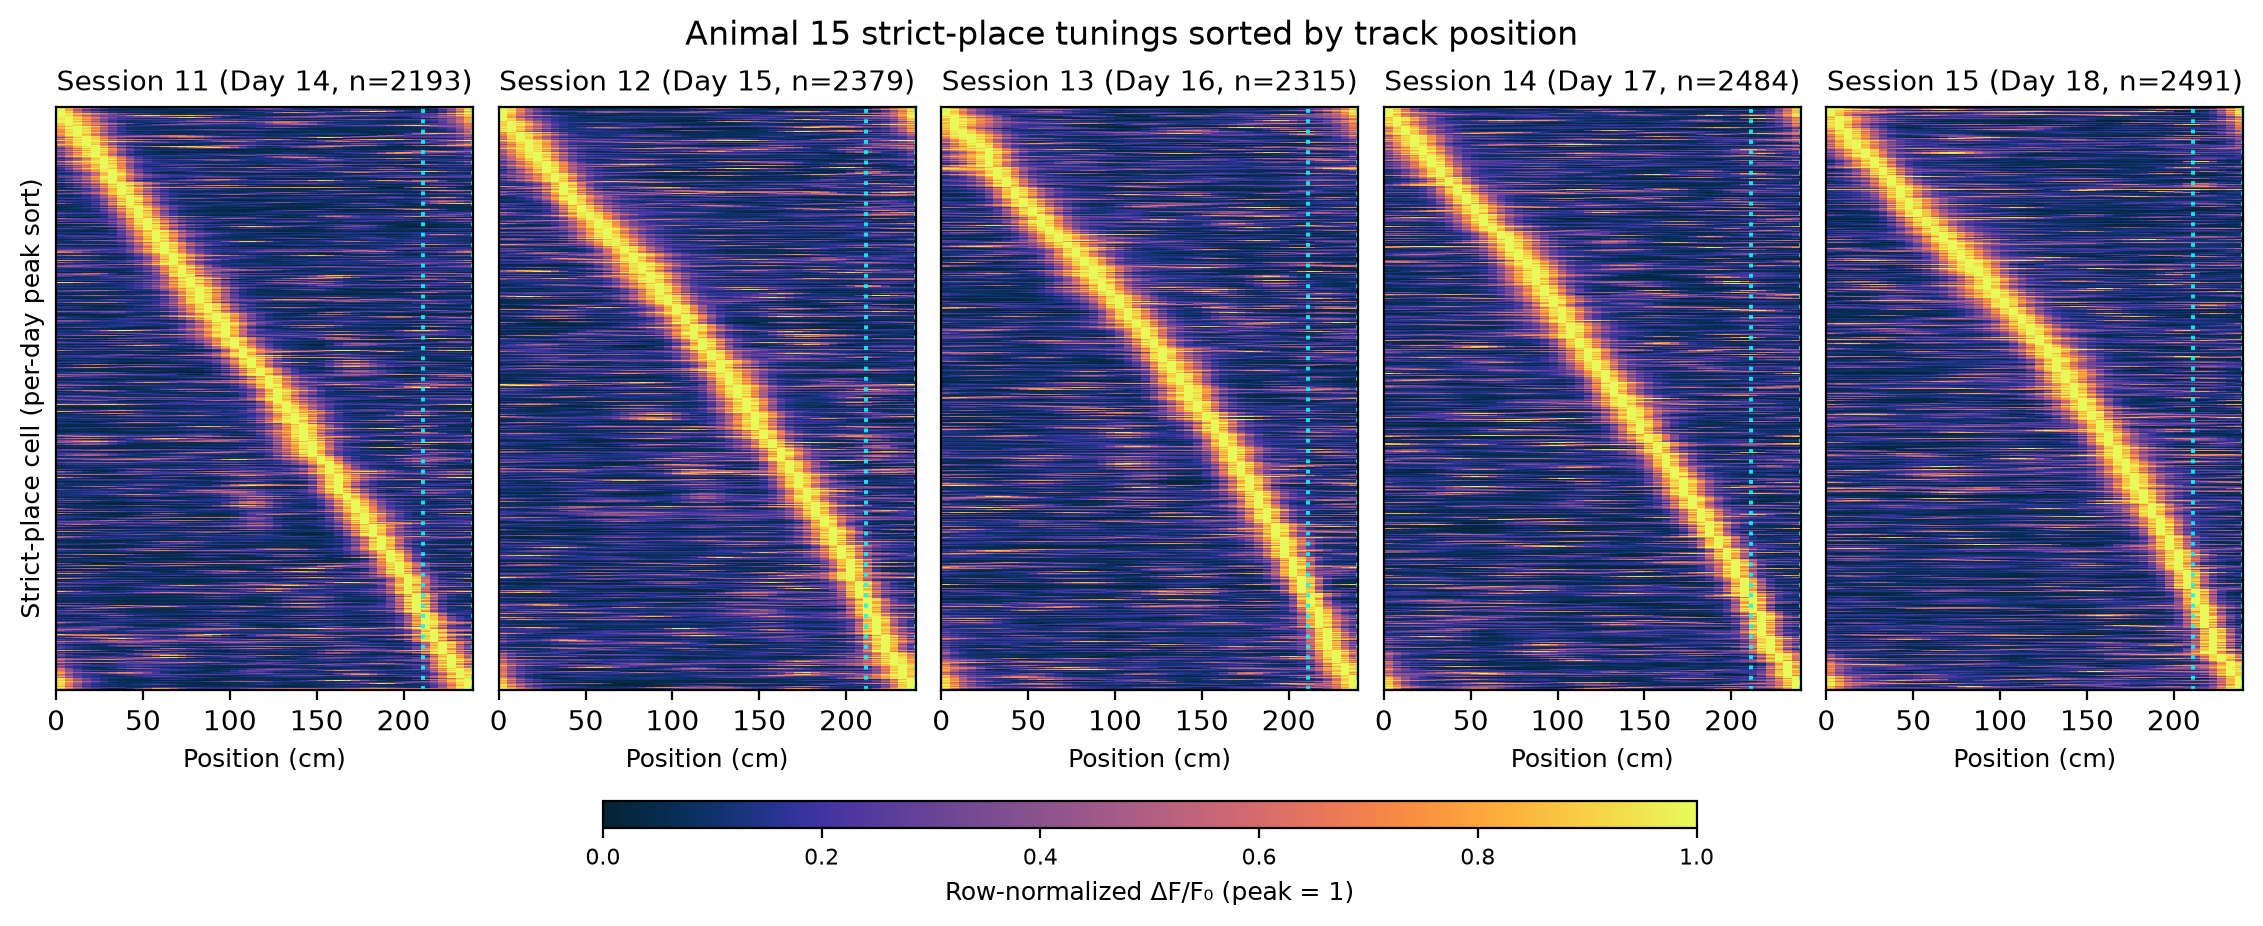

In [8]:
plot_classified_heatmap(
    sessions=sessions,
    classifier="place",  # "place" → IS_STRICT_PLACE; switch to "reward" for IS_REWARD_CELL
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=200,
    cmap="cmo.thermal",
)
plt.show()

### 5.4 Strict-place cells per cue-gray pair

Per-session bar chart of strict-place cell counts binned into ``n_cue_pairs`` uniform-length cue-gray pairs (default 4 — match your trial type). Bars are labelled ``<pair_index>-0`` and pairwise two-sided binomial tests draw thin black ``ns`` brackets above the bars whose ``counts[i] ~ Binomial(counts[i] + counts[j], 0.5)`` null is *not* rejected at p < 0.05; significant pairs render bare. No multiple-comparison correction is applied — interpret with care when ``n_cue_pairs`` is large.

Uses `DISPLAY_SESSIONS` from the selection cell to pick which sessions to render.

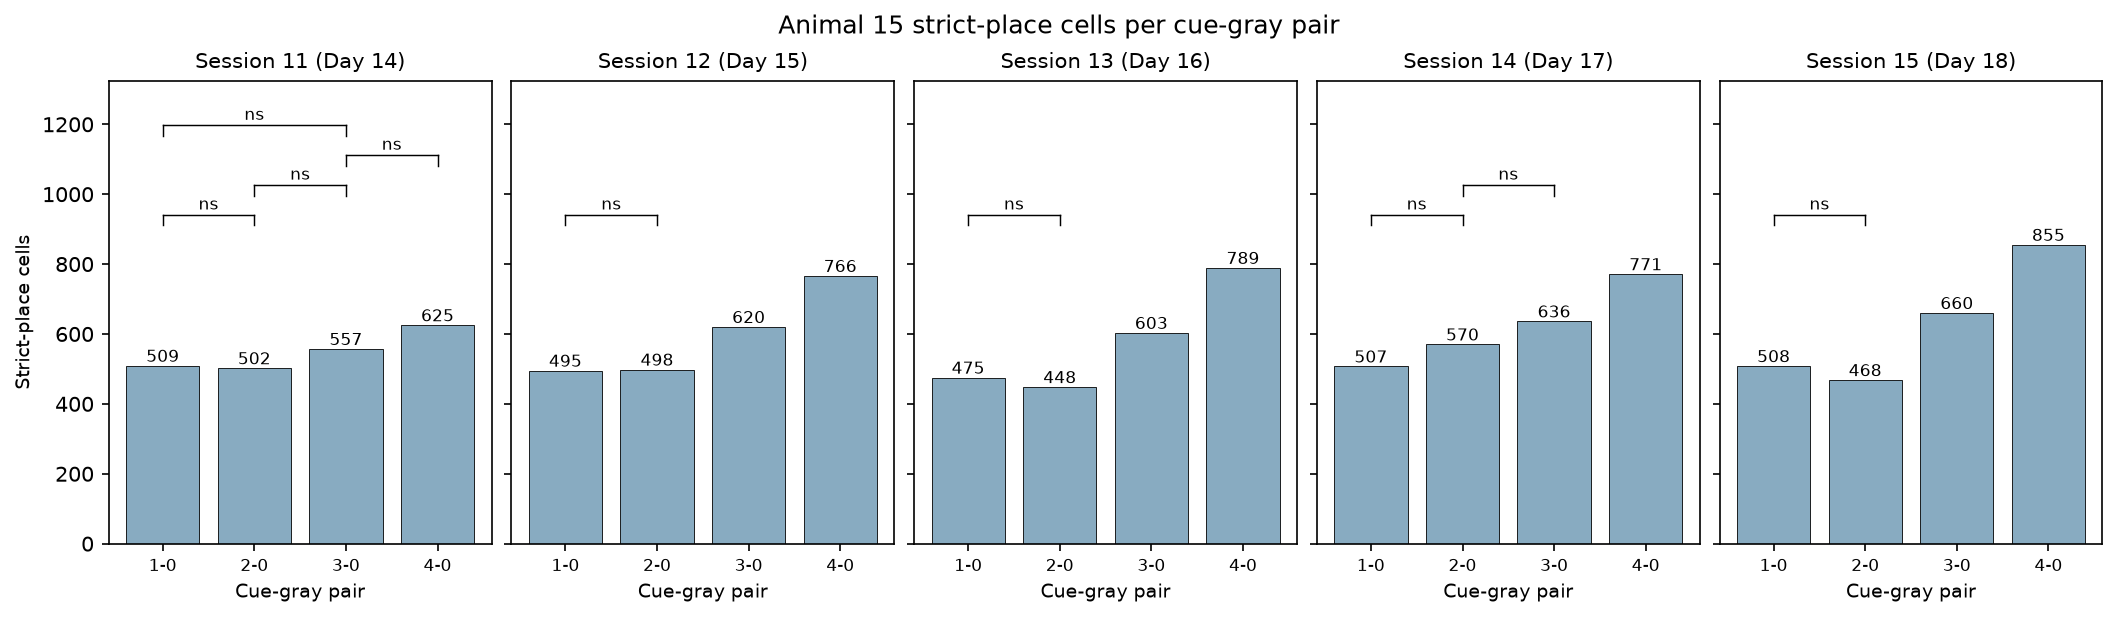

In [9]:
plot_cue_pair_place_counts(
    sessions=sessions,
    trial_type=trial_type,
    animal_id=ANIMAL,
    display_sessions=DISPLAY_SESSIONS,
    figure_dpi=150,
)
plt.show()